In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"D:\__Projects\Customer-Support\Data\Scraped_data\github_issues.csv")

In [3]:
df

,title,body,label
0,dangerous,\nType: <b>Bug</b>\n\nas youcan see not found\...,info-needed
1,Constant Exceeding Rate limit..,\nType: <b>Bug</b>\n\ni am only able to work f...,new release
2,"when multiple confirmations come in, it's not ...",We should alert with the number of pending con...,accessibility
3,copilot hangin,\nType: <b>Bug</b>\n\nJust sat and thought for...,info-needed
4,CoPilot Chat does not work,"\nType: <b>Bug</b>\n\nIt does show ""Language m...",new release
...,...,...,...
4921,Bug,<!-- ⚠️⚠️ Do Not Delete This! bug_report_templ...,spam
4922,"gpt is very poor, do not follow instruction an...",\nType: <b>Bug</b>\n\njust ask anything you wi...,info-needed
4923,attachment styling is bad,"<img width=""712"" height=""612"" alt=""Image"" src=...",bug
4924,G,<!-- ⚠️⚠️ Do Not Delete This! feature_request_...,spam


In [4]:
df["label"].value_counts()

label
info-needed               1691
bug                        782
spam                       511
duplicate                  298
triage-needed              262
                          ... 
inline-chat-affordance       1
model-byok                   1
ai-customizations            1
suggest                      1
gpt                          1
Name: count, Length: 88, dtype: int64

In [5]:
df.isna().sum()

title     2
body     66
label     0
dtype: int64

In [6]:
df.duplicated().sum()

332

In [7]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [8]:
df["label"] = df["label"].str.replace("*", "", regex=False)
df["label"]=df["label"].str.replace("~", " ", regex=False)
df["label"]=df["label"].str.strip()
df["label"]=df["label"].str.lower()

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
df["label"].value_counts()

label
info-needed          1589
bug                   774
duplicate             483
spam                  354
triage-needed         241
                     ... 
ai-customizations       1
suggest                 1
dev-question            1
regression              1
gpt                     1
Name: count, Length: 83, dtype: int64

<Figure size 1000x500 with 0 Axes>

In [10]:
df.shape

(4527, 3)

<Axes: xlabel='label'>

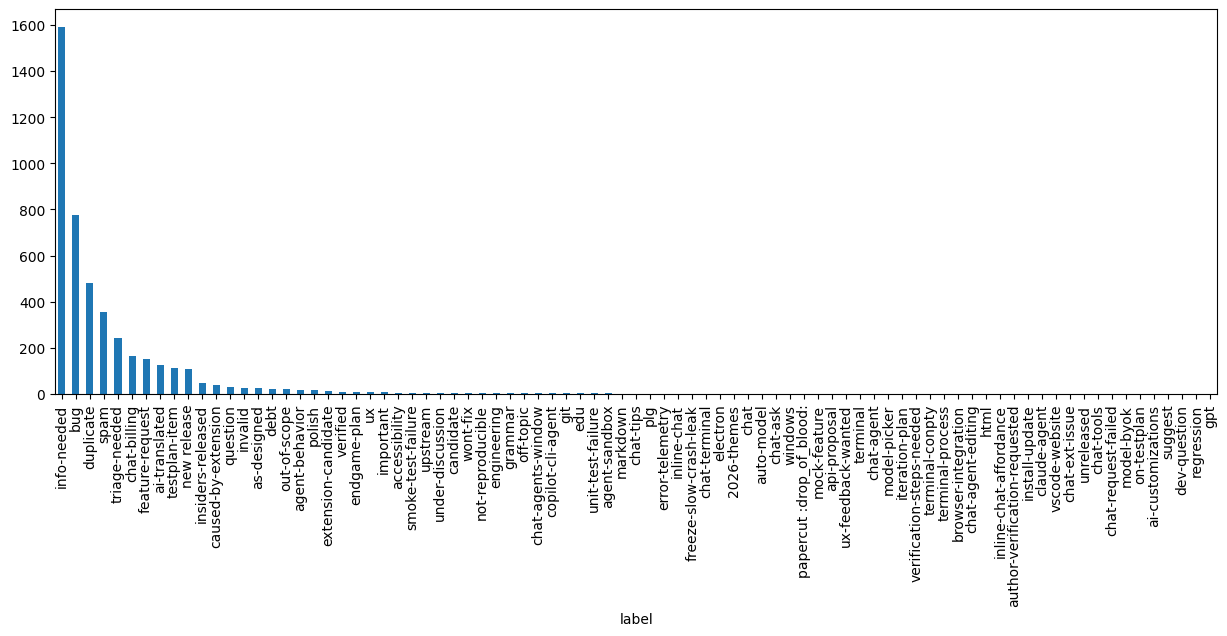

In [11]:
plt.figure(figsize=(15,5))
plt.fontsize=14
df["label"].value_counts().plot(kind="bar")

In [12]:
def label_mapping(label):
    if label in ["spam","invalid"]:
        return "Spam"
    elif label in ["bug","duplicate","caused-by-extension","freeze-slow-crash-leak","unit-test-failure"]:
        return "Bug"
    elif label in ["info-needed","question","author-verification-requested"]:
        return "Support"
    elif label in ["feature-request","enhancement","polish"]:
        return "Feature"
    else:
        return None


In [13]:
df["label"]=df["label"].map(label_mapping)

label
Support    1620
Bug        1303
Spam        381
Feature     168
Name: count, dtype: int64


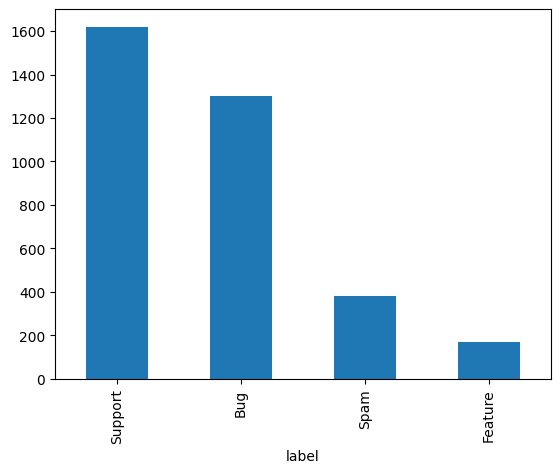

In [14]:
df["label"].value_counts().plot(kind="bar")
print(df["label"].value_counts())

In [15]:
df.isna().sum()

title       0
body        0
label    1055
dtype: int64

In [16]:
df.dropna(inplace=True)

In [17]:
df.shape

(3472, 3)

In [18]:
df["Text"]=df["title"]+" "+df["body"]
df.drop(columns=["title","body"],inplace=True)

In [19]:
df

,label,Text
0,Support,dangerous \nType: <b>Bug</b>\n\nas youcan see ...
3,Support,copilot hangin \nType: <b>Bug</b>\n\nJust sat ...
6,Spam,DUMB AS FUCK \nType: <b>Bug</b>\n\nModel is OL...
8,Spam,error <!-- ⚠️⚠️ Do Not Delete This! bug_report...
10,Bug,code block was not rendered \nType: <b>Bug</b>...
...,...,...
4920,Support,Severe Patch Misapplication Bug in GitHub Copi...
4922,Support,"gpt is very poor, do not follow instruction an..."
4923,Bug,"attachment styling is bad <img width=""712"" hei..."
4924,Spam,G <!-- ⚠️⚠️ Do Not Delete This! feature_reques...


In [20]:
df.duplicated().sum()

3

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.shape

(3469, 2)

In [23]:
label_enc={"Spam":0,"Bug":1,"Support":2,"Feature":3}
df["label"]=df["label"].map(label_enc)
df.rename(columns={"label":"labels"},inplace=True)

In [24]:
from transformers import AutoTokenizer
tok="distilbert-base-uncased"
tokenizer=AutoTokenizer.from_pretrained(tok)


c:\Users\nice\anaconda3\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [25]:
import torch
import gc

def clear_gpu_memory():
    # 1. مسح المتغيرات غير المستخدمة من الرامات العادية
    gc.collect()
    
    # 2. تفضي الـ Cache بتاع الـ PyTorch من الـ GPU
    torch.cuda.empty_cache()
    
    # 3. (اختياري) لو عايز تتأكد إن كل حاجة اتمسحت فعلاً
    with torch.no_grad():
        torch.cuda.empty_cache()
        
    print("GPU memory cleared!")

# استدعي الفانكشن
clear_gpu_memory()

GPU memory cleared!


In [26]:
df

,labels,Text
0,2,dangerous \nType: <b>Bug</b>\n\nas youcan see ...
3,2,copilot hangin \nType: <b>Bug</b>\n\nJust sat ...
6,0,DUMB AS FUCK \nType: <b>Bug</b>\n\nModel is OL...
8,0,error <!-- ⚠️⚠️ Do Not Delete This! bug_report...
10,1,code block was not rendered \nType: <b>Bug</b>...
...,...,...
4920,2,Severe Patch Misapplication Bug in GitHub Copi...
4922,2,"gpt is very poor, do not follow instruction an..."
4923,1,"attachment styling is bad <img width=""712"" hei..."
4924,0,G <!-- ⚠️⚠️ Do Not Delete This! feature_reques...


In [27]:
from datasets import Dataset
from torch import nn
import torch
from transformers import DataCollatorWithPadding, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. تعريف الأوزان (تأكد أن ترتيب الأوزان يطابق ترتيب الـ labels)
class_weights = torch.tensor([4.5, 1.2, 1.0, 6.5])

# 2. تقسيم البيانات (بافتراض وجود df و tokenizer مسبقاً)
df["labels"] = df['labels'].astype(int)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["labels"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["labels"], random_state=42)

train = Dataset.from_pandas(train_df)
val = Dataset.from_pandas(val_df)
test = Dataset.from_pandas(test_df)

def tokenize_function(examples):
    return tokenizer(examples["Text"], truncation=True, padding=False) # Padding يتم عبر الـ Collator

tokenized_train = train.map(tokenize_function, batched=True).remove_columns(["Text"])
tokenized_val = val.map(tokenize_function, batched=True).remove_columns(["Text"])
tokenized_test = test.map(tokenize_function, batched=True).remove_columns(["Text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 3. تحسين الـ Custom Trainer
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # نقل الأوزان لنفس جهاز الموديل (GPU/CPU)
        weights = class_weights.to(model.device)
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

Map:   0%|          | 0/2775 [00:00<?, ? examples/s]

Map:   0%|          | 0/347 [00:00<?, ? examples/s]

Map:   0%|          | 0/347 [00:00<?, ? examples/s]

In [28]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",  # تم التعديل هنا
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="weighted")
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# تأكد من وضع اسم الموديل الصحيح هنا مكان "model_name"
model = AutoModelForSequenceClassification.from_pretrained(tok, num_labels=4)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.810735,0.721975,0.651297,0.697571,0.651297,0.660662
2,0.475831,0.568962,0.789625,0.798531,0.789625,0.792163
3,0.453281,0.687917,0.801153,0.798325,0.801153,0.798407
4,0.246319,0.645013,0.801153,0.806058,0.801153,0.803082


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=696, training_loss=0.5874126445630501, metrics={'train_runtime': 564.3765, 'train_samples_per_second': 19.668, 'train_steps_per_second': 1.233, 'total_flos': 1470440569651200.0, 'train_loss': 0.5874126445630501, 'epoch': 4.0})

In [30]:
import torch
import gc

def clear_gpu_memory():
    # 1. مسح المتغيرات غير المستخدمة من الرامات العادية
    gc.collect()
    
    # 2. تفضي الـ Cache بتاع الـ PyTorch من الـ GPU
    torch.cuda.empty_cache()
    
    # 3. (اختياري) لو عايز تتأكد إن كل حاجة اتمسحت فعلاً
    with torch.no_grad():
        torch.cuda.empty_cache()
        
    print("GPU memory cleared!")

# استدعي الفانكشن
clear_gpu_memory()

GPU memory cleared!


In [34]:
# بعد انتهاء trainer.train()
# الموديل الآن هو الأفضل (Best Model)
metrics = trainer.predict(tokenized_test)
print(metrics.metrics)

{'test_loss': 0.5720592141151428, 'test_accuracy': 0.7896253602305475, 'test_precision': 0.7939283632198926, 'test_recall': 0.7896253602305475, 'test_f1': 0.7907360636309828, 'test_runtime': 5.7761, 'test_samples_per_second': 60.075, 'test_steps_per_second': 3.809}


In [ ]:
def predict_issue(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(model.device)
    outputs = model(**inputs)
    probs = outputs.logits.softmax(dim=-1)
    pred_idx = probs.argmax().item()
    
    labels = ["Spam 📩", "Bug 🐞", "Support/Info ℹ️",'Feature 🚀']
    return labels[pred_idx], probs[0][pred_idx].item()

test_text = ""  # مثال نصي للاختبار
label, confidence = predict_issue(test_text)

print(f"Text: {test_text}")
print(f"Prediction: {label} (Confidence: {confidence:.2%})")

Text: I have a bug with my account
Prediction: Support/Info ℹ️ (Confidence: 76.77%)


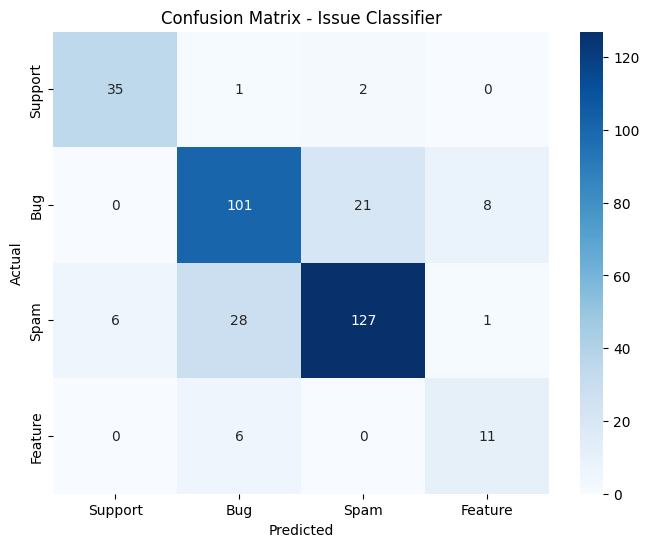

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

predictions = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)
labels = ['Support', 'Bug', 'Spam',"Feature"] 

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Issue Classifier')
plt.show()

In [44]:
model.save_pretrained("./final_issue_model")
tokenizer.save_pretrained("./final_issue_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_issue_model\\tokenizer_config.json',
 './final_issue_model\\tokenizer.json')